# What drives housing prices across European countries?

## Introduction

This project analyzes the relationship between GDP per capita and housing prices across European countries using Eurostat data.

## Research Question

How is GDP per capita related to housing prices and how does this relationship vary across time and country groups?

## Hypotheses

H1: The strength of the relationship between GDP per capita and housing prices changes over time.

H2: Higher-income countries exhibit different housing price levels and variability compared to lower-income countries.

H3: There are statistically significant differences in housing prices between EU and non-EU countries.

## Data load & cleaning

We have a challenge here to align the GDP dataset with the housing dataset, since GDP data used country codes while housing data used full country names. A mapping step was required to ensure correct merging.

In [44]:
## Intall and import dependancies
!pip install scipy
!pip install pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [39]:
housing = pd.read_csv("../data/housing.csv")
gdp = pd.read_csv("../data/gdp.csv")

housing.head()
gdp.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,unit,Unit of measure,na_item,National accounts indicator (ESA 2010),geo,Geopolitical entity (reporting),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
0,dataflow,ESTAT:NAMA_10_PC(1.0),Gross domestic product (GDP) and main componen...,A,Annual,CP_NAC_HAB,"Current prices, units of national currency per...",B1GQ,Gross domestic product at market prices,AL,Albania,2016,NaN,517470,NaN,NaN,NaN,NaN,NaN
1,dataflow,ESTAT:NAMA_10_PC(1.0),Gross domestic product (GDP) and main componen...,A,Annual,CP_NAC_HAB,"Current prices, units of national currency per...",B1GQ,Gross domestic product at market prices,AL,Albania,2017,NaN,549530,NaN,NaN,NaN,NaN,NaN
2,dataflow,ESTAT:NAMA_10_PC(1.0),Gross domestic product (GDP) and main componen...,A,Annual,CP_NAC_HAB,"Current prices, units of national currency per...",B1GQ,Gross domestic product at market prices,AL,Albania,2018,NaN,579410,NaN,NaN,NaN,NaN,NaN
3,dataflow,ESTAT:NAMA_10_PC(1.0),Gross domestic product (GDP) and main componen...,A,Annual,CP_NAC_HAB,"Current prices, units of national currency per...",B1GQ,Gross domestic product at market prices,AL,Albania,2019,NaN,599830,NaN,NaN,NaN,NaN,NaN
4,dataflow,ESTAT:NAMA_10_PC(1.0),Gross domestic product (GDP) and main componen...,A,Annual,CP_NAC_HAB,"Current prices, units of national currency per...",B1GQ,Gross domestic product at market prices,AL,Albania,2020,NaN,583540,NaN,NaN,NaN,NaN,NaN


In [52]:
# GDP cleaning
gdp_clean = gdp[["geo", "TIME_PERIOD", "OBS_VALUE"]].copy()

gdp_clean.columns = ["country_code", "year", "gdp_per_capita"]

gdp_clean["year"] = gdp_clean["year"].astype(int)
gdp_clean["gdp_per_capita"] = pd.to_numeric(gdp_clean["gdp_per_capita"], errors="coerce")

gdp_clean = gdp_clean.dropna()

country_map = {
    "AT": "Austria",
    "DE": "Germany",
    "FR": "France",
    "IT": "Italy",
    "ES": "Spain",
    "BG": "Bulgaria",
    "RO": "Romania",
    "PL": "Poland",
    "NL": "Netherlands",
    "BE": "Belgium",
    "SE": "Sweden",
    "FI": "Finland",
    "DK": "Denmark",
    "GR": "Greece",
    "PT": "Portugal",
    "IE": "Ireland"
}

gdp_clean["country"] = gdp_clean["country_code"].map(country_map)

gdp_clean = gdp_clean.dropna(subset=["country"])

df = pd.merge(
    housing,
    gdp_clean[["country", "year", "gdp_per_capita"]],
    on=["country", "year"]
)

In [51]:
df = housing_yearly.merge(
    gdp_clean,
    on=["country", "year"],
    how="inner"
)

df = df.dropna()

The datasets were merged using country and year as common keys after aligning country naming conventions between the two datasets.

## Exploratory Data Analysis

In [53]:
df.describe()

,year,quarter_num,price_index,quarterly_change_pct,yearly_change_pct,price_change_since_2015_pct,gdp_per_capita
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,2023.750000,2.500000,159.638667,0.917778,3.813889,59.638667,119503.555556
std,0.926789,1.121153,36.808029,1.973403,6.124251,36.808029,168547.635856
min,2022.000000,1.000000,98.280000,-4.700000,-10.200000,-1.720000,13310.000000
25%,2023.000000,1.750000,133.405000,-0.300000,0.025000,33.405000,38070.000000
50%,2024.000000,2.500000,152.790000,1.000000,3.700000,52.790000,52310.000000
75%,2024.250000,3.250000,183.370000,2.225000,7.800000,83.370000,97790.000000
max,2025.000000,4.000000,269.350000,7.100000,18.300000,169.350000,615510.000000


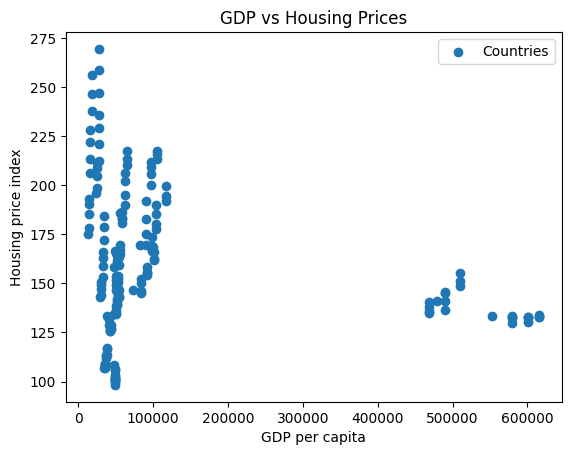

In [63]:
plt.scatter(df["gdp_per_capita"], df["price_index"], label="Countries")

plt.xlabel("GDP per capita")
plt.ylabel("Housing price index")
plt.title("GDP vs Housing Prices")

plt.legend()
plt.show()

The scatter plot shows a non-uniform distribution of points due to the highly skewed nature of GDP per capita and the narrower range of housing price indices. This leads to clustering and uneven dispersion across the axes.